# 6.28 Gauge Invariance in Quantum Mechanics: The Aharonov–Bohm Effect

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume VI — Quantum Mechanics",
    number="6.28",
    title="Gauge Invariance in Quantum Mechanics: The Aharonov–Bohm Effect",
    blurb="A charged particle moves only where E = B = 0, and its interference "
    "pattern shifts anyway. The vector potential of §3.6, introduced as "
    "bookkeeping, turns out to carry physics that no field can: the enclosed "
    "flux, one quantum h/e at a time.",
    difficulty="advanced",
    estimate="90–120 min",
)

<ECP header: 2578 chars of HTML>

## Notebook overview

Volume III built the vector potential three times over: as a device that makes
$\nabla\cdot\mathbf B=0$ automatic ([§3.6](../03-electrodynamics/magnetostatics.ipynb)),
as the gauge-fixed workhorse that decouples Maxwell's equations
([§3.8](../03-electrodynamics/maxwell-waves.ipynb)), and as one half of the
four-potential whose gauge freedom survives every Lorentz transformation
([§3.12](../03-electrodynamics/relativistic-maxwell.ipynb)). At each stage we
promised that quantum mechanics would make this structure *physical*. This
notebook is that promise kept: a coda to Volume VI, after the
[§6.27](quantum-information.ipynb) capstone, closing the arc that began with
a bookkeeping trick.

The vehicle is Aharonov and Bohm's 1959 thought experiment
{cite}`aharonov1959`, now a laboratory fact {cite}`tonomura1986`: an electron
passes on both sides of a thin solenoid, through regions where $\mathbf E$ and
$\mathbf B$ vanish identically, and its two-path interference pattern shifts
by an amount set by the flux $\Phi$ the paths enclose. Nothing local pushed
it. We build the effect from the ground up: minimal coupling on a ring
(a Hamiltonian we diagonalize exactly), gauge transformations verified as
unitaries that move the potential without moving the physics, the line
integral $\oint\mathbf A\cdot d\boldsymbol\ell$ computed over deformed paths
to expose its topological character, the shifted fringes themselves, and
finally the flux quantum $h/2e$ of a superconducting ring: the "discrete
quanta" [§3.7](../03-electrodynamics/induction.ipynb) could only point toward.
Everything is elementary linear algebra and quadrature; the depth is in what
the numbers mean. Griffiths & Schroeter treat the effect in
{cite}`griffiths_qm`; the gauge story's classical half is Jackson's
{cite}`jackson`.

A note on reading the checks in this notebook: a validation compares a result
to an expected physical fact. A ✗ does not by itself mean the answer is
wrong; it means the output did not match what the check expected, which may
be a genuine error, a different-but-valid convention (a sign, an ordering),
or too tight a tolerance. Treat a ✗ as a prompt to locate the discrepancy.
Passing is strong evidence, not proof.

## Theory in brief

**Minimal coupling.** Classically, a charge $q$ in electromagnetic potentials
$(V, \mathbf A)$ has Hamiltonian $H = (\mathbf p - q\mathbf A)^2/2m + qV$; the
canonical momentum $\mathbf p$ and the kinetic momentum
$m\mathbf v = \mathbf p - q\mathbf A$ part company. Quantum mechanics inherits the rule verbatim: in
the position representation of [§6.9](position-representation.ipynb),

```{math}
:label: eq-ab-minimal
\hat H \;=\; \frac{1}{2m}\left(-i\hbar\nabla - q\mathbf A\right)^2 + qV .
```

**Gauge transformations.** The fields are unchanged by
$\mathbf A \to \mathbf A + \nabla\chi$, $V \to V - \partial_t\chi$ for any
smooth $\chi(\mathbf r, t)$ (the freedom of
[§3.6](../03-electrodynamics/magnetostatics.ipynb)). In quantum mechanics the
transformation extends to the state itself:

```{math}
:label: eq-ab-gauge
\mathbf A \to \mathbf A + \nabla\chi,
\qquad
\psi \to e^{\,iq\chi/\hbar}\,\psi ,
```

and {eq}`eq-ab-minimal` transforms covariantly: the transformed pair solves
the same Schrödinger equation. The local phase $e^{iq\chi/\hbar}$ is a
unitary, so spectra, probabilities, and every expectation value are
untouched. Nothing *local* built from $\mathbf A$ alone can be observable.

**What survives the gauge.** One combination of $\mathbf A$ resists being
transformed away. Around a closed loop $\mathcal C$, Stokes's theorem gives
$\oint_{\mathcal C}\mathbf A\cdot d\boldsymbol\ell = \Phi$, the magnetic flux
through the loop, and $\oint\nabla\chi\cdot d\boldsymbol\ell = 0$ for any
single-valued $\chi$. A wavefunction transported around $\mathcal C$ therefore
acquires the gauge-invariant phase

```{math}
:label: eq-ab-phase
\Delta\varphi \;=\; \frac{q}{\hbar}\oint_{\mathcal C}\mathbf A\cdot
d\boldsymbol\ell \;=\; 2\pi\,\frac{\Phi}{\Phi_0},
\qquad
\Phi_0 \equiv \frac{h}{q} ,
```

even when $\mathbf B = 0$ everywhere on the path. The phase depends only on
the flux *enclosed*, not on the loop's shape: it is topological. $\Phi_0$ is
the flux quantum for charge $q$; for an electron, $h/e \approx 4.14\times
10^{-15}$ Wb.

**The ring.** The cleanest home for {eq}`eq-ab-phase` is a particle on a ring
of radius $r$ threaded by flux $\Phi$ (the field confined to the axis, zero
on the ring itself). With $\varphi = \Phi/\Phi_0$ the exact spectrum is

```{math}
:label: eq-ab-ring
E_m(\varphi) \;=\; \frac{\hbar^2}{2 m_e r^2}\,\bigl(m - \varphi\bigr)^2,
\qquad m \in \mathbb Z :
```

a family of parabolas in $\varphi$, one per angular momentum $m$, with the
whole spectrum periodic under $\varphi \to \varphi + 1$. On an $N$-site
discretization the same physics lives in a tight-binding ring whose hopping
elements carry *Peierls phases* $e^{i\theta}$ with $\theta = 2\pi\varphi/N$
per link; its closed-form spectrum, $E_m = 2t\,[1 - \cos(2\pi(m -
\varphi)/N)]$, reduces to {eq}`eq-ab-ring` for the low-lying levels. The
flux also drives a *persistent current* $I = -\partial E/\partial\Phi$: an
equilibrium current in a normal ring, with no battery anywhere.

**The interferometer.** Two paths from source to screen, enclosing flux
$\Phi$ between them, superpose with the relative phase {eq}`eq-ab-phase` on
top of the geometric path difference. For slit separation $d$, screen
distance $L$, and wavelength $\lambda$ (the two-slit geometry of
[§6.13](scattering-tunneling.ipynb)), the intensity on the screen is

```{math}
:label: eq-ab-intensity
I(x) \;=\; 4 I_0\cos^2\!\left(\frac{\pi d x}{\lambda L} +
\pi\frac{\Phi}{\Phi_0}\right):
```

the whole fringe pattern translates by $\Delta x = (\lambda L/d)\,
(\Phi/\Phi_0)$, one full fringe per flux quantum, with the envelope (set by
$|\mathbf B|$ along the paths, which is zero) unmoved. That rigid shift with
nothing local to cause it is the Aharonov–Bohm effect. In a superconductor
the carriers are pairs of charge $2e$, so the period halves: flux through a
superconducting ring is pinned to multiples of $h/2e$, the number
[§3.7](../03-electrodynamics/induction.ipynb) promised. Full treatments:
{cite}`griffiths_qm` §4.5, {cite}`aharonov1959`.

## Setup

Natural units for the ring model ($\hbar = m_e = r = 1$, so $t \equiv
\hbar^2/2m_e a^2$ with $a = 2\pi r/N$ the lattice spacing); SI enters only
where we weigh the real world (Exercises 6 and 7), through
`scipy.constants`. The flux variable throughout is the dimensionless
$\varphi = \Phi/\Phi_0$.

What is here: the ring's geometry ($N = 201$ sites, hopping $t = 1$), the
seeded stream Exercise 1 draws its random gauge function from, the
closed-form ring spectrum the numerical eigenvalues are gated against, and
one instrument — the periodic-trapezoid quadrature that turns a
parameterized closed path into a circulation $\oint\mathbf A\cdot
d\boldsymbol\ell$. The two objects this notebook is *about* are deliberately
absent: you build the Peierls ring Hamiltonian in Exercise 1 and the
two-slit intensity in Exercise 5.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from scipy.constants import e as Q_E  # C, elementary charge
from scipy.constants import h as H_PLANCK  # J s, Planck constant
from scipy.constants import physical_constants

from ecp import animate, draw, validate

# data: the seeded stream Exercise 1 draws its random gauge function from
rng = np.random.default_rng(0)

# data: the ring's discretization and energy scale
N_RING = 201  # sites on the discretized ring (odd, so m and -m pair cleanly)
T_HOP = 1.0  # hopping energy t = ħ²/2m_e a² in natural units


# data: the known closed form of the uniform-flux ring, the target the
# numerical eigenvalues of Exercises 1, 2 and 3 are gated against — a
# transcription of the text's spectrum, not machinery anyone builds here.
def ring_spectrum_exact(phi, n=N_RING):
    """Closed-form spectrum of the uniform-flux Peierls ring.

    The plane waves e^{2πi m j/N} diagonalize the uniform ring exactly, giving
    E_m = 2t[1 - cos(2π(m - φ)/N)]: the discrete ancestor of the (m - φ)²
    parabolas of the text's eq-ab-ring, against which the numerical eigenvalues
    are gated.

    Parameters
    ----------
    phi : float
        Dimensionless flux φ = Φ/Φ₀ through the ring.
    n : int, optional
        Number of sites (default the module's ``N_RING``).

    Returns
    -------
    numpy.ndarray
        The N eigenvalues, sorted ascending.
    """
    m = np.arange(n)
    return np.sort(2.0 * T_HOP * (1.0 - np.cos(2.0 * np.pi * (m - phi) / n)))


# instrument: quadrature, not physics — the lesson of Exercise 4 is that the
# circulation counts windings, and it would read the same had this integral
# come from a library; the numerics here are a thin parameterization around
# numpy.trapezoid.
def loop_integral(a_field, path, dpath, n_pts=4001):
    """∮ A·dl around a closed path, by the periodic trapezoid rule.

    Writes the circulation as ∫₀¹ A(x(s), y(s))·(x'(s), y'(s)) ds and
    integrates with numpy.trapezoid on a uniform s-grid, using the path's
    ANALYTIC tangent (x', y'). Because the integrand is smooth and periodic
    (the path is closed), the trapezoid rule converges spectrally — the same
    fact that makes closed-contour quadrature accurate enough to build a
    residue calculus on, in Volume VII. An estimated tangent (finite
    differences of the samples) would demote the scheme to O(h²); the exact
    tangent keeps it exponential.

    Parameters
    ----------
    a_field : callable
        ``a_field(x, y) -> (Ax, Ay)``, the vector potential, vectorized.
    path : callable
        ``path(s) -> (x, y)`` for s in [0, 1], with path(0) = path(1).
    dpath : callable
        ``dpath(s) -> (dx/ds, dy/ds)``, the analytic tangent of ``path``.
    n_pts : int, optional
        Number of s samples (default ``4001``, far past converged).

    Returns
    -------
    float
        The circulation ∮ A·dl.
    """
    s = np.linspace(0.0, 1.0, n_pts)
    x, y = path(s)
    tx, ty = dpath(s)
    ax_, ay_ = a_field(x, y)
    return float(np.trapezoid(ax_ * tx + ay_ * ty, s))

## Exercise 1 — Gauge covariance, verified as a unitary

Equation {eq}`eq-ab-gauge` claims that adding $\nabla\chi$ to the vector
potential changes nothing physical, provided the state picks up the local
phase $e^{iq\chi/\hbar}$. On the discretized ring the claim becomes concrete.
A gauge function is a value $\chi_j$ per site; the transformation shifts each
link phase by the *difference* across its link and re-phases each amplitude:

$$\theta_j \;\to\; \theta_j + \chi_{j+1} - \chi_j,
\qquad \psi_j \;\to\; e^{\,i\chi_j}\,\psi_j$$

(charge and $\hbar$ absorbed into $\chi$). Because the shifts telescope, the
sum $\sum_j \theta_j = 2\pi\varphi$ around the ring is untouched: a gauge
transformation can slide phase from link to link but cannot change the
winding. That is the entire Aharonov–Bohm effect in one sentence, and this
exercise verifies both halves of it numerically.

**Part a)** Write `ring_hamiltonian(theta_links)`, returning the complex
Hermitian $N\times N$ matrix of the discretized minimal-coupling kinetic
energy {eq}`eq-ab-minimal`: diagonal $H_{jj} = 2t$, hopping
$H_{j,\,j+1} = -t\,e^{-i\theta_j}$ and $H_{j+1,\,j} = -t\,e^{+i\theta_j}$
with the site index taken modulo $N$ (so the last link closes the ring), and
every other entry zero. The $+2t$ diagonal is the discrete Laplacian's, which
puts the band bottom at zero; each hop carries the phase
$(q/\hbar)\int\mathbf A\cdot d\boldsymbol\ell$ across its own link.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Build the uniform ring at $\varphi = 0.3$, $N = 201$: link phases
$\theta_j = 2\pi\cdot 0.3/N$ for every $j$, Hamiltonian from the
`ring_hamiltonian` you just wrote. Verify Hermiticity via the maximum entry
of $|H - H^\dagger|$ (`numpy.abs` on the matrix minus its conjugate
transpose; expect the exact 0.0 of a construction that is Hermitian by
symmetry, not by rounding).

**Part c)** Draw a random gauge function: $\chi_j$ as $N$ independent samples
from `rng.uniform(-np.pi, np.pi)`. Form the gauge-transformed link phases
$\theta_j' = \theta_j + \chi_{j+1 \bmod N} - \chi_j$ and the transformed
Hamiltonian $H'$. Diagonalize both with `numpy.linalg.eigvalsh` and verify
the two spectra agree to machine precision: the physics did not move.

**Part d)** Verify the transformation is exactly the unitary of
{eq}`eq-ab-gauge`: with $U = \mathrm{diag}(e^{i\chi_j})$, check
$H' = U H U^\dagger$ entrywise (`numpy.abs(H2 - U @ H @ U.conj().T).max()`).
Then verify the converse: a deformation that changes the winding is *not* a
gauge transformation. Add $2\pi\cdot 0.2/N$ to every link phase, carrying
the ring from $\varphi = 0.3$ to $\varphi = 0.5$, and verify (ground
state from `numpy.linalg.eigvalsh`, target from `ring_spectrum_exact`)
that it lands on the $\varphi = 0.5$ closed-form value, measurably off the
$\varphi = 0.3$ one (by $\approx 1.6\times10^{-4}\,t$ at $N = 201$). Same
local ingredients; different loop sum; different physics. (A cautionary
footnote from this notebook's own drafting: adding a *full* quantum of
winding, $2\pi/N$ per link, also changes no eigenvalue — but that is
Exercise 2's periodicity at work, not gauge freedom. The loop sum did
change, by exactly the one amount the spectrum cannot see.)

In [3]:
# (solution hidden on the public site)


hermiticity defect      : 0.0e+00
spectrum shift (gauge)  : 3.55e-15
H' - U H U† (entrywise) : 7.45e-16
E0 after winding: 0.000244286119  (phi=0.5: 0.000244286119, phi=0.3: 0.000087944149)


In [4]:
validate.check(
    hermiticity_defect == 0.0,
    "the Peierls ring is Hermitian by construction (defect exactly 0.0)",
    f"max|H - H†| = {hermiticity_defect:.1e}",
)
validate.close(
    spec_2,
    spec_1,
    "a random gauge transformation moves every link phase but no eigenvalue",
    rtol=0.0,
    atol=1e-12,
)
validate.check(
    unitary_defect < 1e-12,
    "the transformation is exactly the unitary U = diag(e^{iχ}): H' = U H U†",
    f"max entry gap {unitary_defect:.1e}",
)
validate.close(
    E0_wound,
    E0_at_05,
    "winding every link by 2π·0.2/N is NOT a gauge move: the ground state "
    "lands on the φ = 0.5 value",
    rtol=1e-10,
)
validate.check(
    abs(E0_wound - E0_at_03) > 1e-4,
    "and that value is measurably away from the φ = 0.3 ground state: the "
    "winding carries physics",
    f"|ΔE₀| = {abs(E0_wound - E0_at_03):.3e}",
)

✓  the Peierls ring is Hermitian by construction (defect exactly 0.0)   [max|H - H†| = 0.0e+00]
✓  a random gauge transformation moves every link phase but no eigenvalue   [max|Δ| = 3.55271e-15 (rtol=0, atol=1e-12)]
✓  the transformation is exactly the unitary U = diag(e^{iχ}): H' = U H U†   [max entry gap 7.4e-16]
✓  winding every link by 2π·0.2/N is NOT a gauge move: the ground state lands on the φ = 0.5 value   [got 0.000244286 vs expected 0.000244286 (rtol=1e-10, atol=1e-09)]
✓  and that value is measurably away from the φ = 0.3 ground state: the winding carries physics   [|ΔE₀| = 1.563e-04]


True

## Exercise 2 — The flux ring: parabolas with period one

With gauge freedom under control, we diagonalize the uniform ring across a
range of flux and confront {eq}`eq-ab-ring`. The discrete ring has the exact
spectrum $E_m = 2t\,[1 - \cos(2\pi(m - \varphi)/N)]$ (each plane wave
$e^{2\pi i m j/N}$ is an eigenvector; the flux shifts the allowed wave
numbers), and for $|m - \varphi| \ll N$ the cosine expands to the continuum
parabolas $(\hbar^2/2m_e r^2)(m - \varphi)^2$. Two facts carry the physics:
the spectrum depends on the flux *at all* (no field touches the ring), and it
is exactly periodic in $\varphi$ with period one, so a whole flux quantum is
invisible.

**Part a)** For $\varphi = 0.3$ and $N = 201$, diagonalize the ring with
`numpy.linalg.eigvalsh` — the matrix from the `ring_hamiltonian` you wrote in
Exercise 1 — and verify the spectrum against the closed form
`ring_spectrum_exact` (expect agreement at `atol=1e-12`; this is an identity,
not an approximation).

**Part b)** Verify the continuum limit: for the same $\varphi$, compare the
five lowest numerical eigenvalues to $t\,(2\pi(m - \varphi)/N)^2$ for
$m \in \{-2, -1, 0, 1, 2\}$ (relative tolerance $10^{-3}$; the residual is
the $\cos$ series' next term, of relative size $(2\pi(m-\varphi)/N)^2/12$).

**Part c)** Verify exact periodicity, $E(\varphi + 1) = E(\varphi)$, by
comparing full sorted spectra at $\varphi = 0.3$ and $\varphi = 1.3$
(`atol=1e-12`), and plot the five lowest levels over $\varphi \in
[-1.5, 1.5]$: the parabola family of {eq}`eq-ab-ring`, crossing at
half-integer flux.

eigh vs closed form : 2.89e-15
continuum residual  : 4.31e-04
E(phi+1) - E(phi)   : 4.44e-15


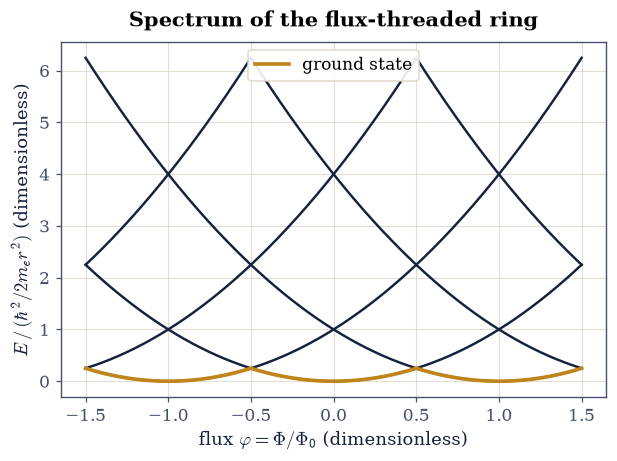

In [5]:
# (solution hidden on the public site)


In [6]:
validate.close(
    spec_num,
    spec_exact,
    "exact diagonalization reproduces the Peierls ring's closed-form spectrum",
    rtol=0.0,
    atol=1e-12,
)
validate.close(
    np.sort(E_low_num),
    np.sort(E_parabola),
    "the five lowest levels sit on the continuum parabolas (m - φ)² "
    "to the stated cos-series accuracy",
    rtol=1e-3,
)
validate.close(
    spec_shifted,
    spec_num,
    "one whole flux quantum is invisible: E(φ + 1) = E(φ) exactly",
    rtol=0.0,
    atol=1e-12,
)

✓  exact diagonalization reproduces the Peierls ring's closed-form spectrum   [max|Δ| = 2.88658e-15 (rtol=0, atol=1e-12)]
✓  the five lowest levels sit on the continuum parabolas (m - φ)² to the stated cos-series accuracy   [max|Δ| = 2.22633e-06 (rtol=0.001, atol=1e-09)]
✓  one whole flux quantum is invisible: E(φ + 1) = E(φ) exactly   [max|Δ| = 4.44089e-15 (rtol=0, atol=1e-12)]


True

## Exercise 3 — The persistent current

A flux-dependent energy is a current. In a ring at equilibrium the flux
derivative of the energy *is* the circulating current,

```{math}
:label: eq-ab-current
I(\varphi) \;=\; -\frac{\partial E}{\partial \Phi}
\;=\; -\frac{1}{\Phi_0}\frac{\partial E}{\partial \varphi} ,
```

the same thermodynamic-derivative move as pressure from $-\partial E/\partial
V$ in Volume V. For the ground state of the ring, {eq}`eq-ab-ring` gives a
current that is linear near $\varphi = 0$, maximal approaching
$\varphi = 1/2$, and then *jumps sign* as the ground state hands over from
$m = 0$ to $m = 1$: a sawtooth with the period of one flux quantum. This is a
persistent current: it flows forever, in a normal (non-superconducting) ring,
with no EMF driving it, exactly the phenomenon
[§3.7](../03-electrodynamics/induction.ipynb) could only name.

**Part a)** Compute the ground-state current in ring units ($\Phi_0 = 1$) at
$\varphi = 0.2$ two ways: by a central difference of the numerical ground
energy, $-[E_0(\varphi + \delta) - E_0(\varphi - \delta)]/2\delta$ with
$\delta = 10^{-6}$ (each $E_0$ from `numpy.linalg.eigvalsh` on your
Exercise 1 `ring_hamiltonian`), and
analytically, by differentiating the $m = 0$ branch $E_0 = 2t[1 -
\cos(2\pi\varphi/N)]$ of the closed-form spectrum:
$I = -(4\pi t/N)\sin(2\pi\varphi/N)$. Verify the two agree to `rtol=1e-6`
(the central difference's $\delta^2$ error sits far below that).

**Part b)** Sweep $\varphi \in [-1.5, 1.5]$ (301 points), computing the
ground-state current by the same central difference, and plot the sawtooth.
Verify the sign flip across $\varphi = 1/2$: the current at $\varphi = 0.45$
is negative and the current at $\varphi = 0.55$ is positive, equal in
magnitude to `rtol=1e-9` by the symmetry $E(\varphi) = E(-\varphi) =
E(1 - \varphi)$.

I(0.2): central diff -3.9086305139e-04  vs analytic -3.9086320067e-04
I(0.45) = -8.794186e-04,  I(0.55) = 8.794192e-04


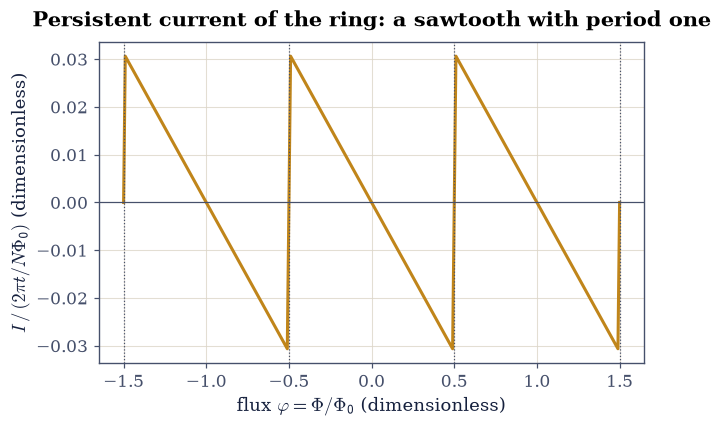

In [7]:
# (solution hidden on the public site)


In [8]:
validate.close(
    I_numeric,
    I_analytic,
    "the persistent current: central difference of E₀ meets the analytic "
    "-(4πt/N) sin(2πφ/N)",
    rtol=1e-6,
)
validate.check(
    I_045 < 0.0 < I_055,
    "the sawtooth jumps sign across φ = 1/2, where the ground state changes "
    "angular momentum",
    f"I(0.45) = {I_045:.3e}, I(0.55) = {I_055:.3e}",
)
validate.close(
    I_055,
    -I_045,
    "the jump is symmetric: E(φ) = E(1 - φ) forces I(0.55) = -I(0.45)",
    rtol=1e-9,
)

✓  the persistent current: central difference of E₀ meets the analytic -(4πt/N) sin(2πφ/N)   [got -0.000390863 vs expected -0.000390863 (rtol=1e-06, atol=1e-09)]
✓  the sawtooth jumps sign across φ = 1/2, where the ground state changes angular momentum   [I(0.45) = -8.794e-04, I(0.55) = 8.794e-04]
✓  the jump is symmetric: E(φ) = E(1 - φ) forces I(0.55) = -I(0.45)   [got 0.000879419 vs expected 0.000879419 (rtol=1e-09, atol=1e-09)]


True

## Exercise 4 — The loop integral is topological

Everything so far *assumed* that only the enclosed flux matters. This
exercise computes it. An ideal solenoid of radius $\rho_0$ on the $z$-axis,
carrying total flux $\Phi$, has (in the symmetric gauge of
[§3.6](../03-electrodynamics/magnetostatics.ipynb)) the exterior vector
potential

```{math}
:label: eq-ab-solenoid
\mathbf A(x, y) \;=\; \frac{\Phi}{2\pi}\,
\frac{(-y,\, x)}{x^2 + y^2},
\qquad \rho > \rho_0 ,
```

whose curl vanishes identically outside the solenoid ($\mathbf B = 0$ where
the particle travels), yet whose circulation $\oint\mathbf A\cdot
d\boldsymbol\ell$ around any loop enclosing the axis equals $\Phi$ by
Stokes's theorem. The circulation cannot change under smooth deformations of
the loop that avoid the solenoid: it counts the *winding number* around the
flux, the topological heart of {eq}`eq-ab-phase`.

{numref}`fig-ab-loops` shows the geometry: the flux region at the origin, and
the three closed paths of Part b).

**Part a)** Implement {eq}`eq-ab-solenoid` with $\Phi = 1$ and verify with
`loop_integral` that the unit circle $\bigl(\cos 2\pi s, \sin 2\pi s\bigr)$,
with its analytic tangent $2\pi(-\sin 2\pi s, \cos 2\pi s)$, gives
$\oint\mathbf A\cdot d\boldsymbol\ell = 1$ to `rtol=1e-9`: the trapezoid
rule in the parameter $s$, fed the exact tangent, is spectrally accurate on
a smooth closed path, and 4001 points is already far past converged. (An
estimated tangent would cost six digits; the helper's docstring says why.)

**Part b)** Deform without fear. Compute the same circulation, with
`loop_integral` and each path's analytic tangent as in Part a), over (i) the
stretched-and-wobbled loop $\bigl(2\cos 2\pi s,\; 1.2\sin 2\pi s + 0.3
\sin 6\pi s\bigr)$, still enclosing the origin once; (ii) the circle of
radius $0.6$ centred at $(3, 0)$, $\bigl(3 + 0.6\cos 2\pi s,\; 0.6\sin 2\pi
s\bigr)$, enclosing nothing; and (iii) the doubly-wound circle
$\bigl(\cos 4\pi s, \sin 4\pi s\bigr)$. Expect $\Phi$, $0$, and $2\Phi$: the
integral counts windings, and nothing else.

**Part c)** Add a gauge term and watch it drop out: with $\chi(x, y) =
0.7\,x y$ (single-valued everywhere), verify that $\mathbf A + \nabla\chi =
\mathbf A + 0.7\,(y,\, x)$ has the same circulation over the unit circle to
`atol=1e-9`. The gauge piece is a gradient; around any closed loop it
integrates to zero.

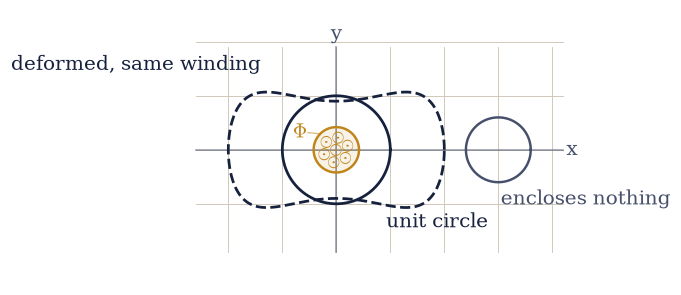

In [9]:
# (solution hidden on the public site)


In [10]:
# (solution hidden on the public site)


unit circle   : 1.000000000000   (expect 1.0)
deformed loop : 1.000000000000   (expect 1.0)
outside loop  : 0.00e+00   (expect 0)
double wind   : 2.000000000000   (expect 2.0)
gauged        : 1.000000000000   (expect 1.0)


In [11]:
validate.close(
    circ_unit,
    PHI_SOLENOID,
    "∮A·dl over the unit circle equals the enclosed flux Φ (Stokes, "
    "spectrally-accurate trapezoid)",
    rtol=1e-9,
)
validate.close(
    [circ_deformed, circ_double],
    [PHI_SOLENOID, 2.0 * PHI_SOLENOID],
    "the circulation is topological: deformation leaves Φ, double winding " "gives 2Φ",
    rtol=1e-6,
)
validate.close(
    circ_outside,
    0.0,
    "a loop that encloses no flux has zero circulation, however close it sits",
    atol=1e-9,
)
validate.close(
    circ_gauged,
    circ_unit,
    "adding ∇(0.7xy) moves A everywhere and the loop integral nowhere",
    atol=1e-9,
)

✓  ∮A·dl over the unit circle equals the enclosed flux Φ (Stokes, spectrally-accurate trapezoid)   [got 1 vs expected 1 (rtol=1e-09, atol=1e-09)]
✓  the circulation is topological: deformation leaves Φ, double winding gives 2Φ   [max|Δ| = 0 (rtol=1e-06, atol=1e-09)]
✓  a loop that encloses no flux has zero circulation, however close it sits   [got 0 vs expected 0 (rtol=1e-06, atol=1e-09)]
✓  adding ∇(0.7xy) moves A everywhere and the loop integral nowhere   [got 1 vs expected 1 (rtol=1e-06, atol=1e-09)]


True

## Exercise 5 — The shifted fringes

Now the experiment itself. An electron leaves a source, passes a double slit,
and lands on a screen; between the paths, behind the slits, sits the thin
solenoid of Exercise 4 ({numref}`fig-ab-experiment`). Each path acquires the
phase $(q/\hbar)\int\mathbf A\cdot d\boldsymbol\ell$ along itself; the
*difference* between the two paths is the closed-loop phase
{eq}`eq-ab-phase`, $2\pi\Phi/\Phi_0$, so the two-slit intensity becomes
{eq}`eq-ab-intensity`: the fringes translate rigidly by $\Delta x =
(\lambda L/d)(\Phi/\Phi_0)$, one full fringe spacing per flux quantum, while
the electron never touches a field. Tonomura's holography experiment
{cite}`tonomura1986` measured exactly this shift with the flux locked inside
a shielded toroidal magnet: the phase difference across the torus was
$\pi$, half a fringe, because the enclosed flux was quantized at $h/2e$
(Exercise 7 explains why that is the superconducting unit).

We use the parameters $d = 1$, $\lambda = 0.05$, $L = 20$ (dimensionless
model units), so the fringe spacing is $\lambda L/d = 1$ exactly.

**Part a)** Write `fringe_intensity(x, phi, d=1.0, lam=0.05,
screen_l=20.0)`, returning {eq}`eq-ab-intensity` in units of the single-slit
intensity $I_0$: $4\cos^2(\pi d x/\lambda L + \pi\varphi)$, with `x` a
`numpy` array of screen positions and `phi` the enclosed flux in quanta.

**Part b)** With that `fringe_intensity`, evaluate $I(x)$ on $x \in [-3, 3]$
(2001 points) for $\Phi/\Phi_0 \in \{0, 1/4, 1/2\}$ and plot the three
patterns. Verify the two structural facts of {eq}`eq-ab-intensity`: the
pattern at $\Phi = \Phi_0$ equals the pattern at $\Phi = 0$ pointwise
(`atol=1e-12`), and at $\Phi = \Phi_0/2$ the central maximum has become an
exact zero, $I(0) = 0$ (`atol=1e-12`): where fringes were brightest,
darkness, with no field touching the electron.

**Part c)** Measure the shift like an experimentalist: for
$\Phi/\Phi_0 = 0.3$, locate the central fringe's maximum by evaluating
$I$ on a fine grid ($10^5$ points on $[-1, 1]$) and taking `numpy.argmax`,
then verify the measured peak position equals $-0.3$ fringe spacings to
`atol=1e-4` (the grid pitch; the sign says which way the fringes march:
toward the path with the *lagging* phase).

**Part d)** Animate the march: ramp $\Phi$ from $0$ to $2\Phi_0$ over 80
frames and animate $I(x)$ with a marker riding the central maximum. The
validation checks the animated *data*: the marker's trajectory across the
ramp is the straight line $x_{\max} = -(\Phi/\Phi_0)$ fringe spacings,
wrapped to the central period.

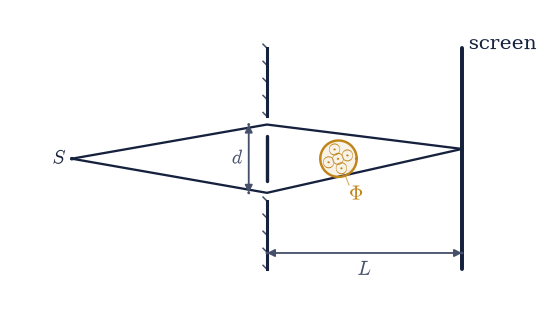

In [12]:
# (solution hidden on the public site)


In [13]:
# (solution hidden on the public site)


|I(Phi_0) - I(0)|_max : 4.44e-15
I(0) at half quantum  : 1.50e-32
peak at phi = 0.3     : -0.30000  (expect -0.30000)


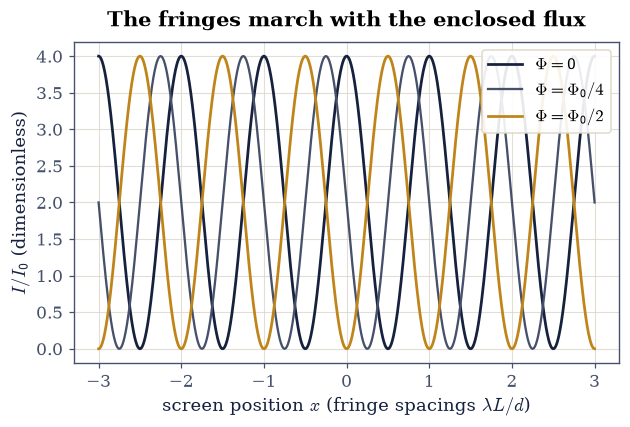

In [14]:
# (solution hidden on the public site)


In [15]:
# (solution hidden on the public site)


In [16]:
validate.close(
    I_full,
    I_0,
    "one flux quantum restores the pattern pointwise: I(x; Φ₀) = I(x; 0)",
    rtol=0.0,
    atol=1e-12,
)
validate.close(
    center_at_half,
    0.0,
    "at Φ = Φ₀/2 the central bright fringe is an exact zero",
    atol=1e-12,
)
validate.close(
    x_peak,
    -PHI_MEAS,
    "the measured peak position is -(Φ/Φ₀) fringe spacings: the predicted "
    "fringe shift, read off the screen",
    atol=1e-4,
)
validate.close(
    np.array(
        [float(x_fine[np.argmax(fringe_intensity(x_fine, p))]) for p in (0.1, 0.35)]
    ),
    np.array([-0.1, -0.35]),
    "the animated marker's law holds across the ramp: the central maximum "
    "tracks x = -(Φ/Φ₀) within the central period",
    atol=1e-4,
)

✓  one flux quantum restores the pattern pointwise: I(x; Φ₀) = I(x; 0)   [max|Δ| = 4.44089e-15 (rtol=0, atol=1e-12)]
✓  at Φ = Φ₀/2 the central bright fringe is an exact zero   [got 1.49976e-32 vs expected 0 (rtol=1e-06, atol=1e-12)]
✓  the measured peak position is -(Φ/Φ₀) fringe spacings: the predicted fringe shift, read off the screen   [got -0.3 vs expected -0.3 (rtol=1e-06, atol=0.0001)]
✓  the animated marker's law holds across the ramp: the central maximum tracks x = -(Φ/Φ₀) within the central period   [max|Δ| = 2.77556e-17 (rtol=1e-06, atol=0.0001)]


True

## Exercise 6 — The scale of the effect

How big is a flux quantum? For a single electron, {eq}`eq-ab-phase` sets
$\Phi_0 = h/e$: two exactly-defined SI constants (both fixed by definition
since 2019), so $\Phi_0$ is exact. The striking part is how *small* it is,
and therefore how accessible the effect: a micron-scale ring encloses one
flux quantum in a field a refrigerator magnet would embarrass.

**Part a)** Compute $\Phi_0 = h/e$ from `scipy.constants` (`h` and `e`)
and verify it equals $4.135667696\times 10^{-15}$ Wb to `rtol=1e-9`
(the 2018 CODATA value is exact; the check pins the displayed digits).

**Part b)** For a ring of radius $r = 1\ \mu\mathrm m$, compute the uniform
field that threads exactly one flux quantum through its area, $B = \Phi_0 /
(\pi r^2)$, and verify $B = 1.316\ \mathrm{mT}$ to `rtol=1e-3`: about
forty times the Earth's field, trivially achievable, which is why
Aharonov–Bohm oscillations are a standard laboratory sight in mesoscopic
rings. Then compute the phase Tonomura's toroid imprinted: an enclosed flux
of $h/2e$ in {eq}`eq-ab-phase` gives $\Delta\varphi = \pi$ exactly, half a
fringe, the displacement his holograms show.

In [17]:
# (solution hidden on the public site)


Phi_0 = h/e        : 4.135667697e-15 Wb
B for one quantum  : 1.3164 mT  (r = 1 um)
Tonomura's phase   : 1.000000000000 pi


In [18]:
validate.close(
    flux_quantum_e,
    4.135667696e-15,
    "the electron's flux quantum h/e, from the exact SI h and e",
    rtol=1e-9,
)
validate.close(
    B_ONE_QUANTUM,
    1.316e-3,
    "one flux quantum through a 1 μm ring needs only B = 1.316 mT",
    rtol=1e-3,
)
validate.close(
    tonomura_phase,
    np.pi,
    "an enclosed h/2e imprints a phase of exactly π: Tonomura's half fringe",
    rtol=1e-12,
)

✓  the electron's flux quantum h/e, from the exact SI h and e   [got 4.13567e-15 vs expected 4.13567e-15 (rtol=1e-09, atol=1e-09)]
✓  one flux quantum through a 1 μm ring needs only B = 1.316 mT   [got 0.00131642 vs expected 0.001316 (rtol=0.001, atol=1e-09)]
✓  an enclosed h/2e imprints a phase of exactly π: Tonomura's half fringe   [got 3.14159 vs expected 3.14159 (rtol=1e-12, atol=1e-09)]


True

## Exercise 7 — Flux quantization: a promise delivered

[§3.7](../03-electrodynamics/induction.ipynb) ended with a pointer this
course could then only state: flux trapped in a superconducting ring comes in
"discrete quanta $h/2e$". The machinery of this notebook explains both the
quantization and the puzzling factor of two.

In a superconductor the carriers condense into a single macroscopic
wavefunction $\Psi = \sqrt{n_s}\,e^{i\vartheta}$ (Volume VII builds the
statistical mechanics behind such condensates). Deep inside the ring the
current density vanishes, which pins the phase gradient to the vector
potential: $\hbar\nabla\vartheta = q\mathbf A$. Integrating around the ring
and demanding $\Psi$ be single-valued ($\oint\nabla\vartheta\cdot
d\boldsymbol\ell = 2\pi n$, $n\in\mathbb Z$) forces

```{math}
:label: eq-ab-quantization
\Phi \;=\; n\,\frac{h}{q} .
```

The measured unit is $h/2e$, not $h/e$: the carriers have charge $q = 2e$,
because they are Cooper *pairs*. Flux quantization is therefore a
charge-counting experiment, and it voted for pairing before the microscopic
theory could explain it.

**Part a)** The pair charge halves the period, and the ring of Exercise 2
shows it directly. For charge $q = 2e$ the link phases double,
$\theta_j = 2\pi(2\varphi)/N$ with $\varphi = \Phi/(h/e)$ still measured in
*electron* flux quanta. Verify with `numpy.linalg.eigvalsh` on your
Exercise 1 `ring_hamiltonian` that the full
spectrum at $\varphi = 0.2$ equals the spectrum at $\varphi = 0.7$
(`atol=1e-12`): for pairs, the period in $\Phi$ is $h/2e$, half the
electron's. Plot the two ground-state curves $E_0(\varphi)$ for $q = e$ and
$q = 2e$ over $\varphi\in[0, 1]$; the doubled charge traces two periods
where the single charge traces one.

**Part b)** Compute $h/2e$ from `scipy.constants` and verify it against the
CODATA-listed magnetic flux quantum,
`physical_constants["mag. flux quantum"]` $= 2.067833848\times10^{-15}$ Wb,
to `rtol=1e-10`: the constant the metrologists tabulate *is* the
superconducting unit, delivered here from first principles.

pair spectrum, phi=0.2 vs 0.7 : 2.66e-15
h/2e            : 2.067833848e-15 Wb
CODATA tabulated: 2.067833848e-15 Wb


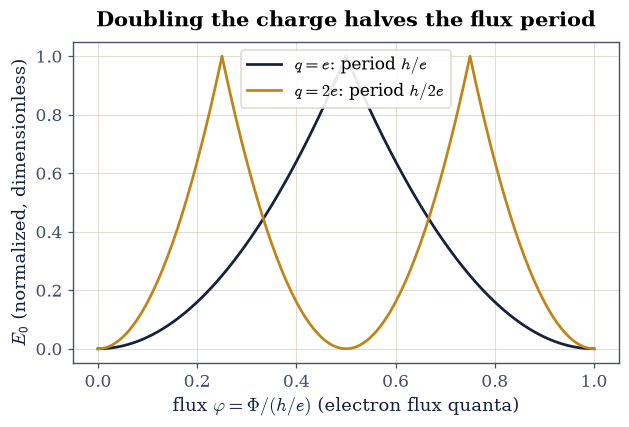

In [19]:
# (solution hidden on the public site)


In [20]:
validate.close(
    spec_pair_07,
    spec_pair_02,
    "for charge-2e carriers the spectrum repeats after HALF an electron flux "
    "quantum: the pair's period is h/2e",
    rtol=0.0,
    atol=1e-12,
)
validate.close(
    flux_quantum_sc,
    flux_quantum_codata,
    "h/2e equals the CODATA magnetic flux quantum: the discrete unit "
    "promised in §3.7, now derived",
    rtol=1e-10,
)

✓  for charge-2e carriers the spectrum repeats after HALF an electron flux quantum: the pair's period is h/2e   [max|Δ| = 2.66454e-15 (rtol=0, atol=1e-12)]
✓  h/2e equals the CODATA magnetic flux quantum: the discrete unit promised in §3.7, now derived   [got 2.06783e-15 vs expected 2.06783e-15 (rtol=1e-10, atol=1e-09)]


True

## Exercise 8 — The arc, closed (a reading exercise)

No computation here; read this the way the Epilogue reads the course.

Track what the vector potential has been, volume by volume. In
[§3.6](../03-electrodynamics/magnetostatics.ipynb) it was a *device*:
$\mathbf B = \nabla\times\mathbf A$ made $\nabla\cdot\mathbf B = 0$
automatic, and the gauge freedom looked like a defect to be managed. In
[§3.8](../03-electrodynamics/maxwell-waves.ipynb) the freedom became a
*tool*: the Lorenz gauge decoupled Maxwell's equations into wave equations.
In [§3.12](../03-electrodynamics/relativistic-maxwell.ipynb) it became
*structure*: $A^\mu$ assembled into a four-vector, and gauge invariance
survived every boost. This notebook made it *physics*: the loop integral of
$\mathbf A$, the one gauge-proof thing it carries, moves interference
fringes and pins the flux in superconducting rings, in regions where every
field is zero.

The pattern, one more volume out, runs the other way: in quantum
electrodynamics one *starts* from the local phase freedom
{eq}`eq-ab-gauge` and derives the existence of $\mathbf A$, of Maxwell's
equations, of the photon, as the price of making the symmetry local. Gauge
invariance stops being a property of electromagnetism and becomes its
*origin*, and the same logic (with grander symmetry groups) builds the rest
of the Standard Model. That story is beyond this course; the Aharonov–Bohm
effect is where it becomes impossible to dismiss.

One more horizon deserves its name. The phase {eq}`eq-ab-phase` is the
simplest example of a *geometric phase*: a phase acquired from the path
traversed, not the time elapsed. Berry showed in 1984 {cite}`berry1984` that
the same structure appears whenever a quantum system is carried slowly
around a closed circuit in *any* parameter space, with the Aharonov–Bohm
effect as the special case where the parameter is position around a flux.
Berry phases now organize whole subjects (molecular dynamics near level
crossings, the modern theory of polarization, topological band structure);
the reader who wants the general machinery starts with his paper, carrying
this notebook's flux ring as the worked example.

## Notebook summary

- A random per-site gauge transformation moved every link phase of the
  $N = 201$ Peierls ring and no eigenvalue (agreement at $10^{-12}$), and
  was exactly the unitary $U = \mathrm{diag}(e^{i\chi_j})$ of
  {eq}`eq-ab-gauge`; winding the links by $2\pi\cdot0.2/N$, by contrast,
  raised the enclosed flux from $\varphi = 0.3$ to $0.5$ and moved the ground
  state onto the $\varphi = 0.5$ value. Only the loop sum is physical.
- Exact diagonalization reproduced the ring's closed-form spectrum to
  $10^{-12}$ and the continuum parabolas $(\hbar^2/2m_e r^2)(m - \varphi)^2$
  of {eq}`eq-ab-ring` to the stated $10^{-3}$; the spectrum was exactly
  periodic under $\varphi \to \varphi + 1$.
- The flux derivative {eq}`eq-ab-current` produced the persistent-current
  sawtooth: central differences met $-(4\pi t/N)\sin(2\pi\varphi/N)$ to
  $10^{-6}$, with the symmetric sign jump at half-integer flux.
- The circulation $\oint\mathbf A\cdot d\boldsymbol\ell$ of the solenoid
  potential {eq}`eq-ab-solenoid` was $\Phi$ on the unit circle and on a
  deformed loop, $2\Phi$ on a double winding, $0$ on a non-enclosing loop,
  and unmoved by the gauge term $\nabla(0.7xy)$: a winding counter, to ten
  digits, by the trapezoid rule.
- The two-slit pattern {eq}`eq-ab-intensity` marched by exactly
  $-(\Phi/\Phi_0)$ fringe spacings (measured by peak location to $10^{-4}$),
  restored itself at one flux quantum, and zeroed its central fringe at
  half a quantum; Tonomura's enclosed $h/2e$ imprints exactly $\pi$.
- The scales: $\Phi_0 = h/e = 4.135667696\times10^{-15}$ Wb exactly, one
  quantum through a 1 μm ring at $B = 1.316$ mT; and for charge-$2e$
  carriers the ring's period halved (spectra at $\varphi = 0.2$ and $0.7$
  equal to $10^{-12}$), with $h/2e$ matching the CODATA magnetic flux
  quantum to $10^{-10}$: the [§3.7](../03-electrodynamics/induction.ipynb) promise, delivered.

## Outlook

- **Berry phases** {cite}`berry1984`. The flux ring is the archetype of a
  geometric phase; the general theory replaces "position around a solenoid"
  with any slow closed circuit in parameter space, and its curvature
  reappears in the anomalous velocity of Bloch electrons and the
  classification of topological bands.
- **Mesoscopic rings.** In normal-metal rings below a micron, the
  $h/e$-periodic persistent current of Exercise 3 and Aharonov–Bohm
  conductance oscillations are routine measurements; disorder averages the
  $h/e$ component and reveals an $h/2e$ harmonic with a different origin
  (time-reversed path pairs) than the superconducting unit.
- **Superconducting quantization in the laboratory.** SQUIDs count flux in
  units of $h/2e$ and are the most sensitive magnetometers built; the same
  quantization underlies the fluxonium and flux qubits of the hardware
  [§6.27](quantum-information.ipynb) treated abstractly.
- **Local gauge symmetry as a construction principle.** Demanding
  {eq}`eq-ab-gauge` locally *generates* electromagnetism; Volume VII's Coda
  ([§7.23](../07-quantum-statistical-mechanics/second-quantization.ipynb))
  builds the many-body language in which that construction is written.

### References

```{bibliography}
:filter: docname in docnames
```

In [21]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>